## 1. Configuração do Ambiente e Importação de Bibliotecas

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2 # ou outra arquitetura como VGG16, ResNet50

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [ ]:
import os
import shutil

# Definir caminhos
base_dir = '/content/dataset'
folders = [
    'train/carro', 'train/moto',
    'validation/carro', 'validation/moto'
]

# Criar diretórios
for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

# Mover os arquivos carregados para a estrutura (Exemplo simples: 1 para treino, 1 para validação)
# Nota: Em um projeto real, você precisaria de muito mais imagens.
try:
    shutil.copy('/content/Carro1.png', f'{base_dir}/train/carro/Carro1.png')
    shutil.copy('/content/Carro2.png', f'{base_dir}/validation/carro/Carro2.png')
    shutil.copy('/content/Moto1.png', f'{base_dir}/train/moto/Moto1.png')
    shutil.copy('/content/Moto2.png', f'{base_dir}/validation/moto/Moto2.png')
    print("Estrutura de diretórios criada e imagens organizadas!")
except FileNotFoundError as e:
    print(f"Erro: Certifique-se de que os arquivos Carro1, Carro2, Moto1 e Moto2 estão em /content. {e}")

Estrutura de diretórios criada e imagens organizadas!


In [ ]:
# Carrega os datasets novamente com a estrutura correta
train_dataset = image_dataset_from_directory(
    f'{dataset_path}/train',
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataset = image_dataset_from_directory(
    f'{dataset_path}/validation',
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Otimização
train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2 files belonging to 2 classes.
Found 2 files belonging to 2 classes.


In [ ]:
# 1. Definir a arquitetura usando MobileNetV2
base_model = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 2. Compilar
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Treinar (Consolidado)
print("Iniciando o treinamento com MobileNetV2...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Iniciando o treinamento com MobileNetV2...
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5000 - loss: 0.6755 - val_accuracy: 0.5000 - val_loss: 0.5469
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 1.0000 - loss: 0.1975 - val_accuracy: 1.0000 - val_loss: 0.4025
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 1.0000 - loss: 0.0686 - val_accuracy: 1.0000 - val_loss: 0.3297
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 1.0000 - loss: 0.0307 - val_accuracy: 1.0000 - val_loss: 0.3009
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 1.0000 - loss: 0.0162 - val_accuracy: 1.0000 - val_loss: 0.2922
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 0.2907
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.2918
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 1.0000 - loss: 0

In [ ]:
# Defina os caminhos para o seu dataset
dataset_path = '/content/dataset' # Mude para o caminho do seu dataset

# Defina parâmetros para o carregamento das imagens
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

# Carrega os datasets de treinamento e validação
train_dataset = image_dataset_from_directory(
    f'{dataset_path}/train',
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataset = image_dataset_from_directory(
    f'{dataset_path}/validation',
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Imprime as classes detectadas
class_names = train_dataset.class_names
print(f"Classes encontradas: {class_names}")

# Otimiza o desempenho do I/O de dados
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 2 files belonging to 2 classes.
Found 2 files belonging to 2 classes.
Classes encontradas: ['carro', 'moto']


## 3. Construindo o Modelo de Transfer Learning

Vamos usar o MobileNetV2 sem a camada superior e congelar seus pesos originais.

In [ ]:
# 1. Carregar o modelo base pré-treinado
base_model = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), include_top=False, weights='imagenet')

# 2. Congelar o modelo base para não perder o conhecimento prévio
base_model.trainable = False

# 3. Adicionar novas camadas para a nossa tarefa (Carro vs Moto)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x) # Camada de saída binária

model = Model(inputs=base_model.input, outputs=predictions)

# 4. Compilar
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 4. Testar com suas próprias imagens
Use o botão abaixo para fazer upload de uma imagem do seu PC e ver a classificação.

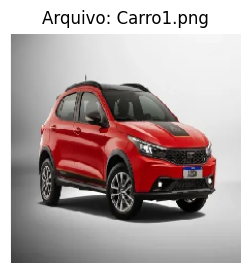

Predição: CARRO (Score: 0.4108)
------------------------------


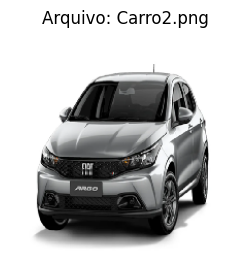

Predição: CARRO (Score: 0.3801)
------------------------------


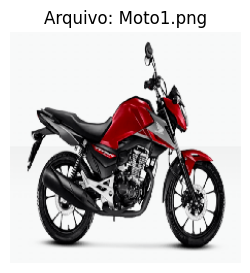

Predição: MOTO (Score: 0.5545)
------------------------------


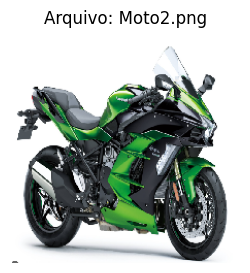

Predição: MOTO (Score: 0.5455)
------------------------------


In [ ]:
import os
from tensorflow.keras.preprocessing import image

# Lista das imagens carregadas
image_files = ['Carro1.png', 'Carro2.png', 'Moto1.png', 'Moto2.png']

for fn in image_files:
    path = os.path.join('/content', fn)

    if os.path.exists(path):
        img = image.load_img(path, target_size=(IMG_WIDTH, IMG_HEIGHT))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = x / 255.0

        prediction = model.predict(x, verbose=0)

        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title(f"Arquivo: {fn}")
        plt.axis('off')
        plt.show()

        # 0 geralmente é a primeira classe alfabética (Carro), 1 é a segunda (Moto)
        if prediction[0] > 0.5:
            print(f"Predição: MOTO (Score: {prediction[0][0]:.4f})")
        else:
            print(f"Predição: CARRO (Score: {prediction[0][0]:.4f})")
        print("-" * 30)
    else:
        print(f"Arquivo {fn} não encontrado.")